# 01. Exploratory Data Analysis — Home Credit Default Risk

Цель ноутбука — посмотреть на данные перед моделированием:
- структура и типы признаков;
- баланс классов;
- пропуски;
- распределения ключевых признаков (EXT_SOURCE_*, возраст, доход, сумма кредита);
- корреляции с TARGET.

Если реального CSV из Kaggle нет — модуль `src.data` автоматически сгенерирует синтетический датасет с той же схемой.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from src.utils.config import TrainConfig
from src.data.dataset import load_dataset, NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET

cfg = TrainConfig.load()
df = load_dataset(cfg)
df.shape

2026-05-26 13:06:56 | INFO    | src.data.dataset | Loading dataset from /Users/v.razon/Desktop/вуз/ml/mirea-aie-project/project/data/raw/application_train.csv


2026-05-26 13:06:56 | INFO    | src.data.dataset | Loaded 50000 rows; positive rate = 0.0604


(50000, 25)

## Баланс классов

Доля дефолтов должна быть около 8% — это типично для скоринга и важно для дальнейшего выбора метрик и порога.

Positive (default) rate: 0.0604


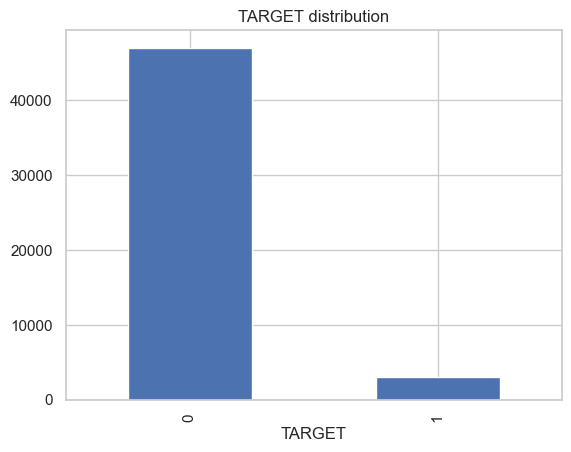

In [2]:
target_rate = df[TARGET].mean()
print(f'Positive (default) rate: {target_rate:.4f}')
df[TARGET].value_counts().plot.bar(); plt.title('TARGET distribution'); plt.show()

## Пропуски

EXT_SOURCE_* — основная фича датасета, и у неё много пропусков. Это особенность задачи.

In [3]:
missing = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].isna().mean().sort_values(ascending=False)
missing[missing > 0]

EXT_SOURCE_1       0.55944
OCCUPATION_TYPE    0.30028
EXT_SOURCE_3       0.19774
DAYS_EMPLOYED      0.18016
EXT_SOURCE_2       0.00522
CODE_GENDER        0.00100
dtype: float64

## Распределение ключевых числовых признаков

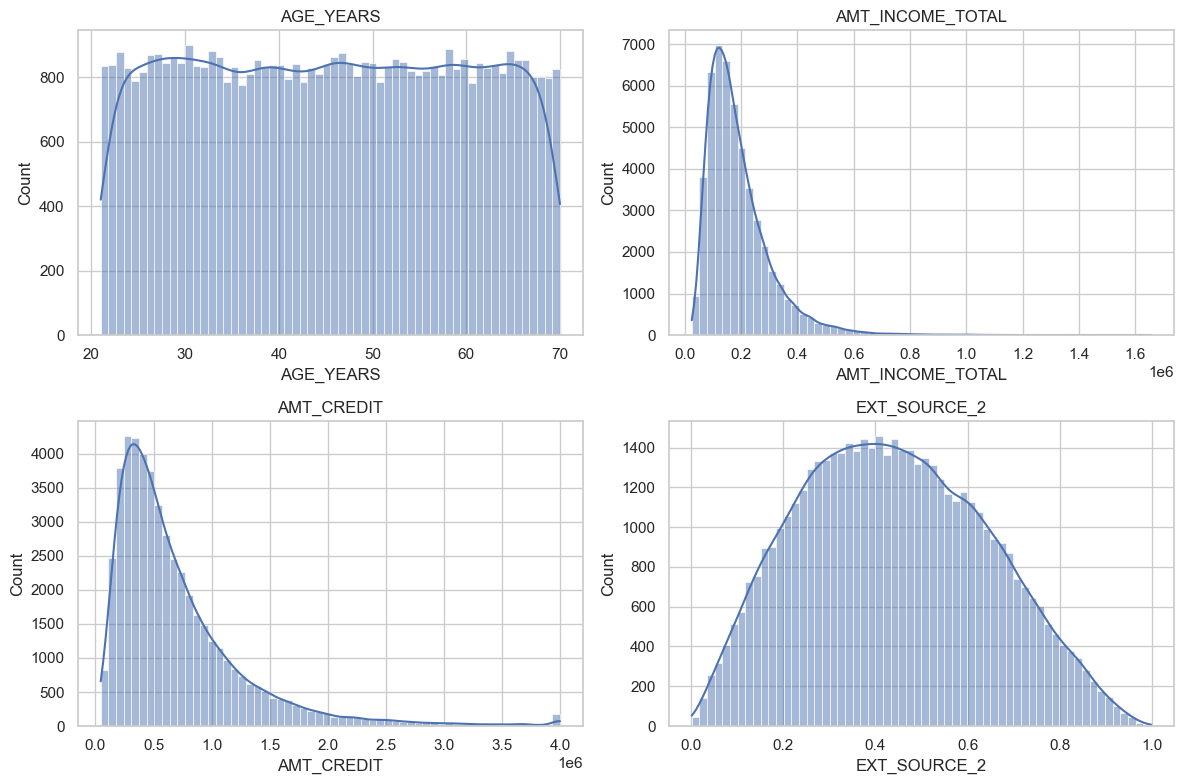

In [4]:
df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365.0

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, ['AGE_YEARS', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'EXT_SOURCE_2']):
    sns.histplot(df[col].dropna(), bins=60, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

## EXT_SOURCE — самые сильные признаки

Сравним распределения по классам. У дефолтников среднее EXT_SOURCE заметно ниже.

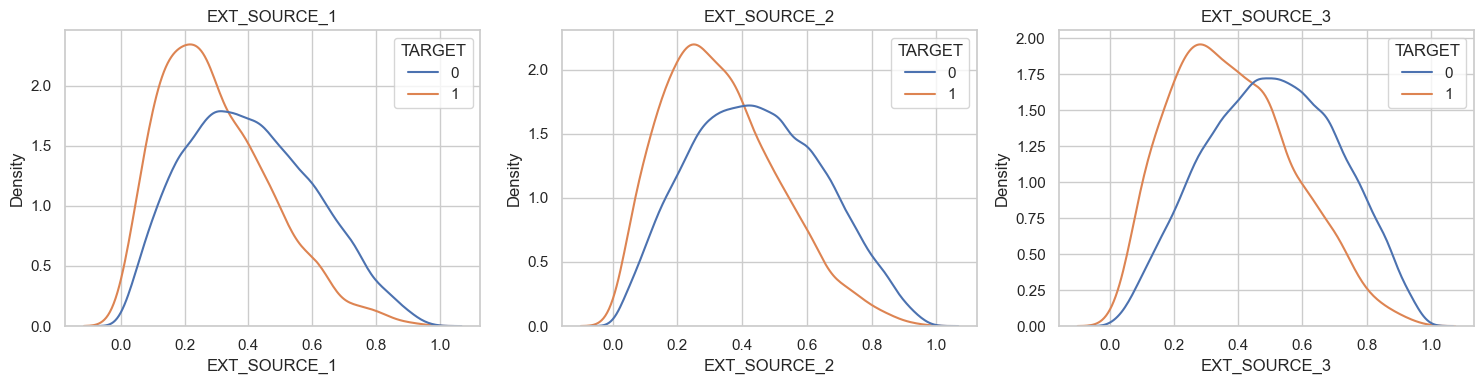

EXT_SOURCE_1    TARGET=0: 0.406  TARGET=1: 0.298
EXT_SOURCE_2    TARGET=0: 0.447  TARGET=1: 0.336
EXT_SOURCE_3    TARGET=0: 0.506  TARGET=1: 0.383


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    sns.kdeplot(data=df, x=col, hue=TARGET, common_norm=False, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    means = df.groupby(TARGET)[col].mean()
    print(f'{col:14s}  TARGET=0: {means.get(0, float("nan")):.3f}  TARGET=1: {means.get(1, float("nan")):.3f}')

## Корреляции с TARGET (числовые)

Используем Pearson — он даёт грубый ориентир, какие признаки несут сигнал.

In [6]:
corr = df[NUMERIC_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
corr

EXT_SOURCE_3                 -0.146512
EXT_SOURCE_1                 -0.131318
EXT_SOURCE_2                 -0.130629
DAYS_EMPLOYED                 0.090617
DAYS_BIRTH                    0.089970
AMT_ANNUITY                   0.018114
AMT_CREDIT                    0.016583
AMT_GOODS_PRICE               0.015964
AMT_INCOME_TOTAL             -0.006480
DAYS_ID_PUBLISH              -0.004671
DAYS_REGISTRATION             0.002670
CNT_FAM_MEMBERS               0.002290
REGION_POPULATION_RELATIVE   -0.001190
CNT_CHILDREN                 -0.000118
Name: TARGET, dtype: float64

## Дефолт по уровню образования

In [7]:
edu = df.groupby('NAME_EDUCATION_TYPE')[TARGET].agg(['mean', 'count']).sort_values('mean', ascending=False)
edu

,mean,count
NAME_EDUCATION_TYPE,,
Lower secondary,0.094737,760
Secondary / secondary special,0.064896,35626
Incomplete higher,0.062987,1667
Higher education,0.044403,11891
Academic degree,0.017857,56


## Выводы для моделирования

1. Классы сильно несбалансированы (~6-8% положительных) → нужно использовать ROC-AUC / PR-AUC, и/или class_weight='balanced'.
2. EXT_SOURCE_1/2/3 — самые сильные одиночные признаки, у них много пропусков → нужна импутация (медианой) или модель, умеющая работать с NaN (LightGBM).
3. Низкое образование и короткий стаж — повышенный риск.
4. Возраст и доход коррелируют с TARGET слабее, но являются стандартными скоринг-признаками — оставляем.